In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

### Feature Scaling and Feature Selection

Direction
Up      648
Down    602
Name: count, dtype: int64


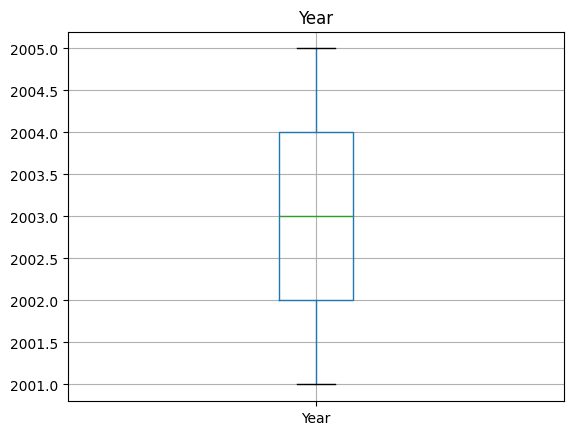

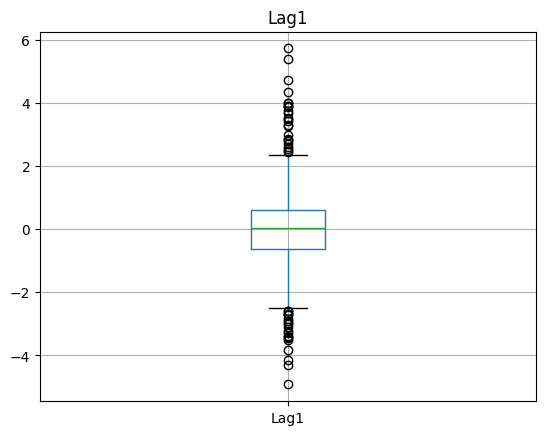

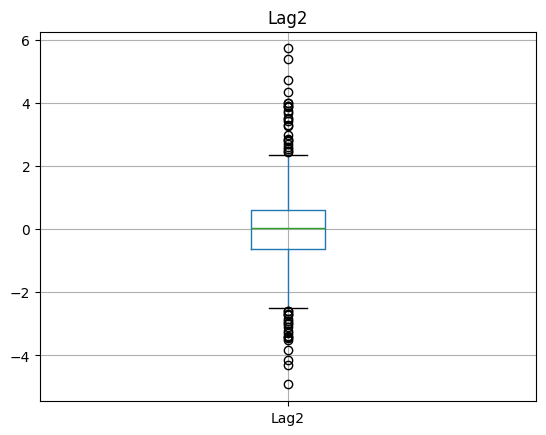

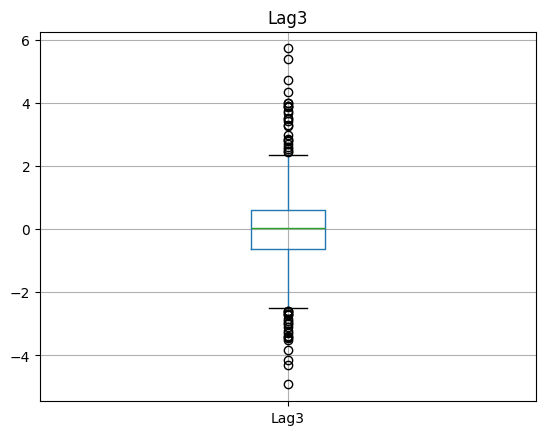

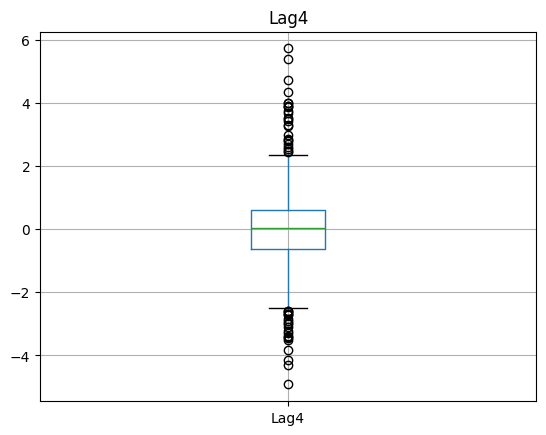

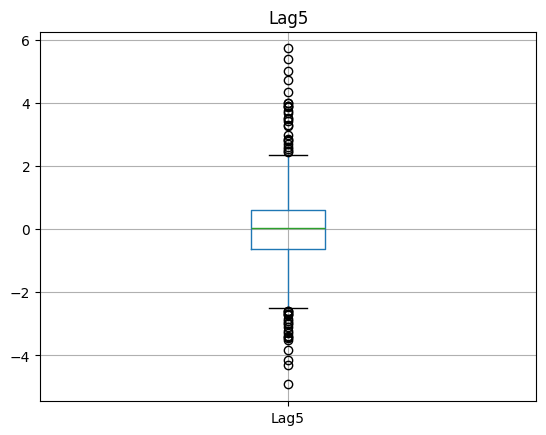

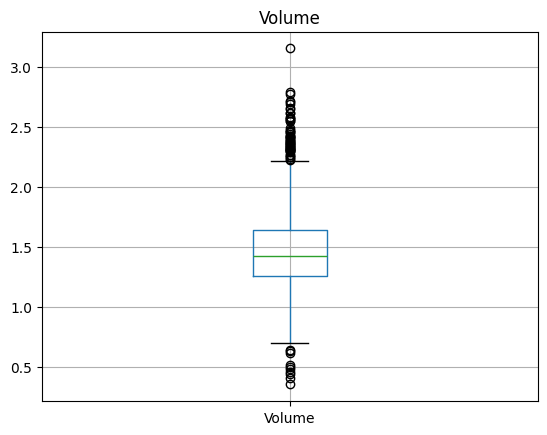

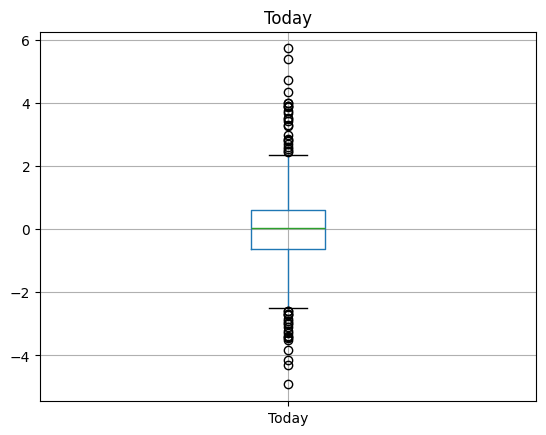

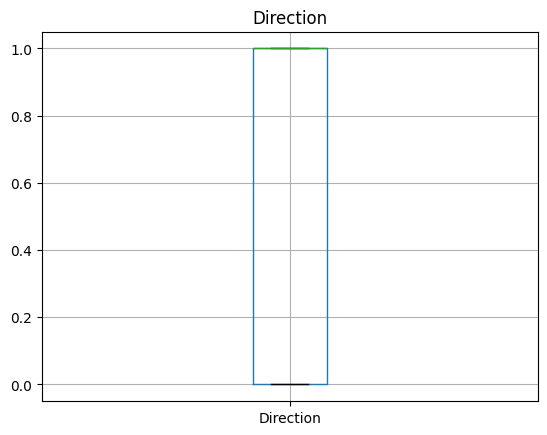

In [ ]:
#Understanding the dataset
df=pd.read_csv('./dataset/Smarket.csv')
df.dropna()
df.describe()
print(df["Direction"].value_counts())

#Encoding the target variable 
df["Direction"] = df["Direction"].map({
    "Up":1,
    "Down":0
})
#df.hist(figsize=(15,12))
for col in df.columns:
    df.boxplot(column=col)
    plt.title(col) 
    plt.show()
    

Year      0
Lag1      0
Lag2      0
Lag3      0
Lag4      0
Lag5      0
Volume    0
Today     0
dtype: int64

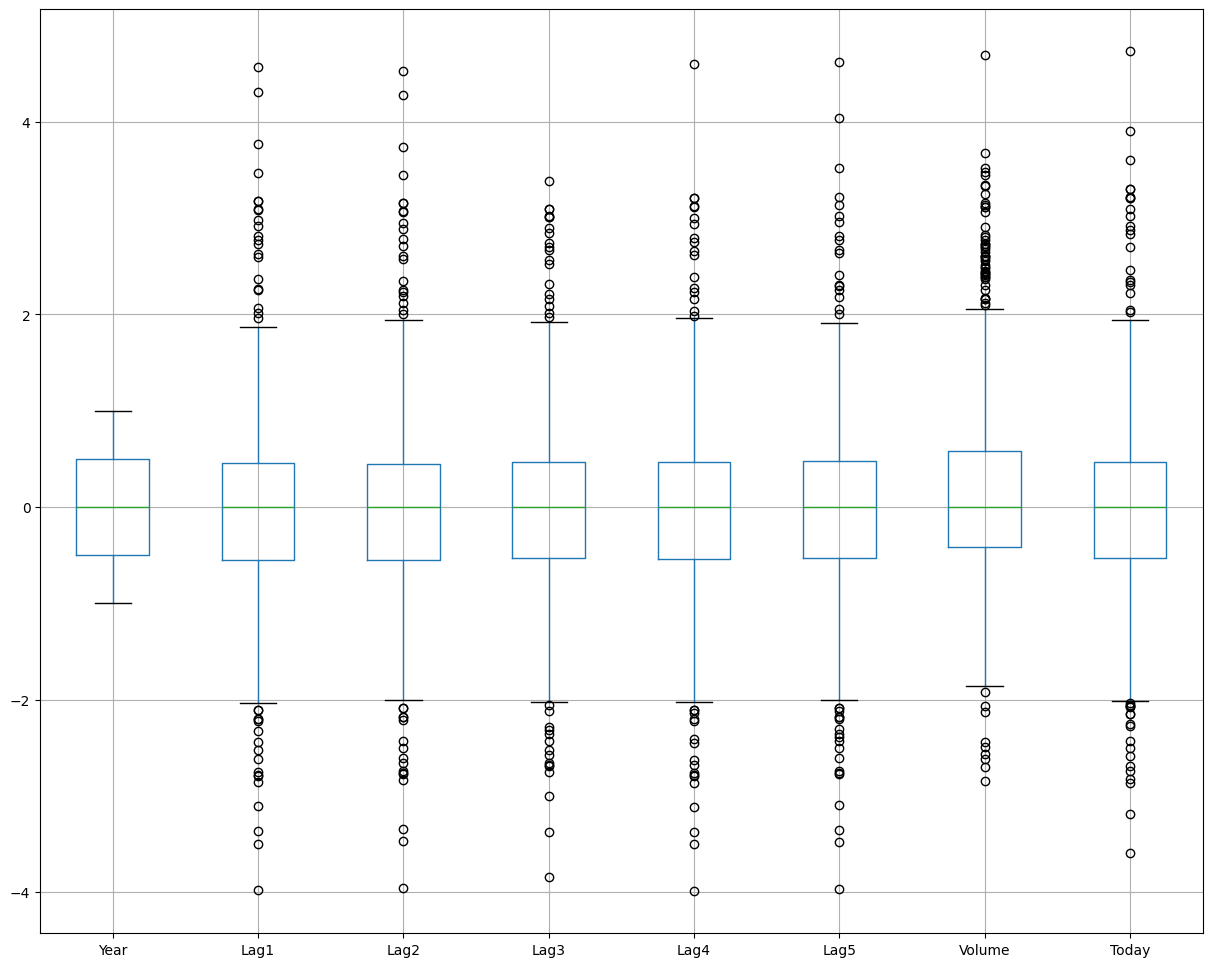

In [44]:
SEED = 445
train_set= df.sample(frac=0.75,random_state=SEED)
test_set=df.drop(train_set.index)

X_train=train_set.drop("Direction",axis=1)
Y_train=train_set["Direction"].copy()

X_test=test_set.drop("Direction",axis=1)
Y_test=test_set["Direction"].copy()

#Scaling 
#From the boxplot its clear that the dataset has lot of outliers . So we will use robust scaling to scale the df
median=X_train.median()
q1=X_train.quantile(0.25)
q3=X_train.quantile(0.75)
IQR=q3-q1
X_train_scaled=(X_train-median)/IQR
X_test_scaled=(X_test-median)/IQR

X_train_scaled.boxplot(figsize=(15,12))
X_train_scaled.isnull().sum()

### Sigmoid and Logistic Loss

In [3]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_loss(X,y, w,b, lbd):
    m ,n= X.shape[0]
    loss = 0.0
    for i in range(m):
        z = np.dot(X[i],w)+b
        f_wb = sigmoid(z)
        loss += -y[i]*np.log(f_wb) - (1-y[i])*np.log(1-f_wb) 

    for i in range(n):
        reg += w[i]**2

    reg_term = (lbd/(2*m)) * reg

    total_cost = (loss/m) + reg_term
        
    return total_cost


In [ ]:
def compute_gradient(X, y, w, b, lbd):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        z = np.dot(X[i], w) + b
        f_wb = sigmoid(z)
        error = f_wb - y[i]

        dj_db += error

        for j in range(n):
            dj_dw[j] += error * X[i, j]

    

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    for j in range(n):
        dj_dw[j] += (lbd / m) * w[j]

    return dj_dw, dj_db

def gradient_descent(X_train, y_train, compute_cost, compute_gradient, l_rate, iter, w_i, b_i, lbd):

    J_hist = []
    param_hist = []
    iteration = []
    b = b_i
    w = w_i


    for i in range(iter):
        dj_dw,dj_db = compute_gradient(X_train,y_train, w, b, lbd)

        w = w - (dj_dw * l_rate)
        b = b - (dj_db * l_rate)

       

        if(i%(math.ceil(iter/10)) == 0):
            iteration.append(i)
            J_hist.append(compute_cost(X_train, y_train, w,b))
            param_hist.append([w,b])
            print(f"iteration: {i} || Cost: {J_hist[-1]}")

            
    return w,b, J_hist, param_hist, iteration
